## Examine the ERA5 Land-Sea mask

#### From the documentation(https://codes.ecmwf.int/grib/param-db/172): This parameter is the proportion of land, as opposed to ocean or inland waters (lakes, reservoirs, rivers and coastal waters), in a grid box.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [55]:
# input file is downloading one day's land-sea mask variable
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-Full-LSM-download.nc'
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 8MB
Dimensions:    (longitude: 1440, latitude: 721, time: 1)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 8B 2023-09-01T12:00:00
Data variables:
    lsm        (time, latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-04 22:47:42 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [56]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = ds.coords['longitude'].attrs  
lat_atrib = ds.coords['latitude'].attrs
ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
ds = ds.sortby(ds.longitude)
ds

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 721, time: 1, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 8B 2023-09-01T12:00:00
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    lsm        (time, latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-04 22:47:42 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [57]:
# also save that out because that is how I will want the longitude
# also rename to lat and lon like the t2m data
ds = ds.rename({'longitude':'lon','latitude':'lat'})
ds = ds.mean(dim='time') # get rid of time dimension since there is only one value
ds.coords['lon'].attrs = lon_atrib
ds.coords['lat'].attrs = lat_atrib
output_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds.to_netcdf(output_path)
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0 1.0

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

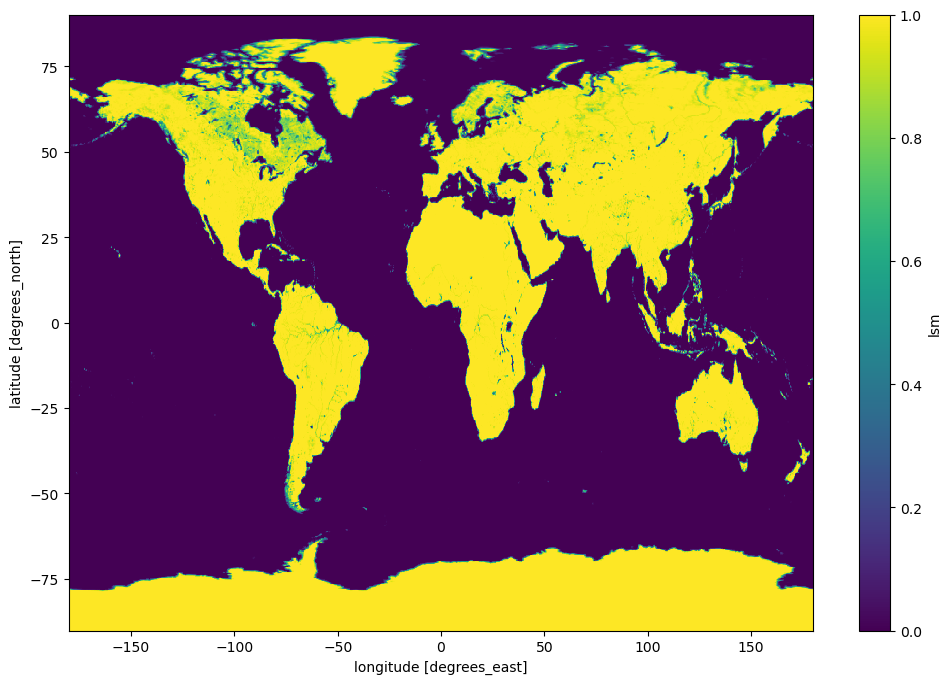

In [3]:
plt.figure(figsize=(12,8))
ds.lsm.plot()